

## 1 вариант: medical_diagnosis.csv

**Цель работы:** Изучение алгоритмов и методов кластеризации на практике с использованием датасета о медицинской диагностике.

## Часть 1: Создание и анализ синтетического датасета

### Импорт необходимых библиотек

Импортируем все необходимые библиотеки для работы с данными, машинным обучением и визуализацией.

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import fowlkes_mallows_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

np.random.seed(0)

### Функция для создания синтетического датасета

Создаём функцию, которая генерирует датасет с тремя группами точек с разными параметрами распределения.

In [29]:
def make_data(n, seed):
    np.random.seed(seed)
    shift_matrix = np.array(
        [
            [3, 3],
            [6, 9],
            [9, 3]
        ]
    )
    data = np.random.randn(3, 2, n) + shift_matrix.reshape((3, 2, 1))
    data = np.swapaxes(data, 1, 2)
    data = data.reshape((-1, 2))
    df = pd.DataFrame(
        {
            'x': data[:, 0],
            'y': data[:, 1]
        },
        columns=['x', 'y']
    )
    df = df.sample(frac=1.0)
    return df

### Создание датасета Часть 1

Применяем функцию для создания синтетического датасета. Выбираем параметр n от 30 до 100.

In [82]:
n = 50
df_part1 = make_data(n, seed=0)
print(f"Размер датасета Части 1: {df_part1.shape}")
print(f"\nПервые 20 строк:")
display(df_part1.head(20))
print(f"\nОписательная статистика:")
display(df_part1.describe())

Размер датасета Части 1: (150, 2)

Первые 20 строк:


,x,y
19,2.145904,3.051945
103,9.655264,2.680672
14,3.443863,3.177426
117,9.379152,3.088422
60,7.867559,8.501968
94,8.383145,9.523277
13,3.121675,1.273717
133,9.416050,4.536377
147,10.079619,3.582954
11,4.454274,2.640447



Описательная статистика:


,x,y
count,150.000000,150.000000
mean,6.090785,4.964274
std,2.562900,2.961568
min,0.447010,0.227407
25%,3.957251,2.650503
50%,6.386216,3.553422
75%,8.397799,8.130117
max,11.259309,11.163236


### **Стандартизация данных**
Выполняем стандартизацию случайных данных для корректного отображения:

In [83]:
scaler = StandardScaler()
df_part1_scaled = scaler.fit_transform(df_part1)

print(f"Среднее значение после стандартизации: {df_part1_scaled.mean(axis=0)[:2]}")
print(f"Стандартное отклонение после стандартизации: {df_part1_scaled.std(axis=0)[:2]}")
print(f"\nДанные готовы к кластеризации")

Среднее значение после стандартизации: [-5.92118946e-18 -2.96059473e-16]
Стандартное отклонение после стандартизации: [1. 1.]

Данные готовы к кластеризации


### K-means кластеризация для 3 кластеров

Применяем алгоритм K-means с количеством кластеров, равным 3. Это должно соответствовать трём группам в синтетическом датасете.

In [84]:
kmeans_3 = KMeans(n_clusters=3, random_state=0)
labels_3 = kmeans_3.fit_predict(df_part1_scaled)

display(labels_3)
print(f"Количество кластеров: {len(np.unique(labels_3))}")
print(f"Уникальные метки кластеров: {np.unique(labels_3)}")
print(f"Количество объектов в каждом кластере: {np.bincount(labels_3)}")
print(f"\nЦентры кластеров (в стандартизованном пространстве):")
print(kmeans_3.cluster_centers_)

array([1, 0, 1, 0, 2, 2, 1, 0, 0, 1, 2, 0, 0, 0, 1, 1, 1, 1, 2, 1, 1, 2,
       0, 0, 2, 0, 1, 2, 0, 0, 1, 0, 1, 2, 1, 0, 0, 0, 1, 2, 0, 0, 2, 1,
       2, 1, 2, 1, 1, 2, 0, 1, 2, 0, 1, 2, 2, 2, 0, 1, 0, 2, 2, 1, 1, 2,
       1, 1, 1, 0, 2, 1, 2, 1, 1, 2, 0, 1, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2,
       1, 2, 1, 2, 1, 0, 0, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1, 1, 1, 0, 1, 2,
       0, 1, 0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0,
       0, 1, 2, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2, 1, 0, 2, 0], dtype=int32)

Количество кластеров: 3
Уникальные метки кластеров: [0 1 2]
Количество объектов в каждом кластере: [50 50 50]

Центры кластеров (в стандартизованном пространстве):
[[ 1.09009516 -0.66335116]
 [-1.15498451 -0.67257208]
 [ 0.06488935  1.33592323]]


### Визуализация кластеров для K=3

Визуализируем результаты кластеризации на скаттер-графике, выделяя кластеры разными цветами и отмечая центры.

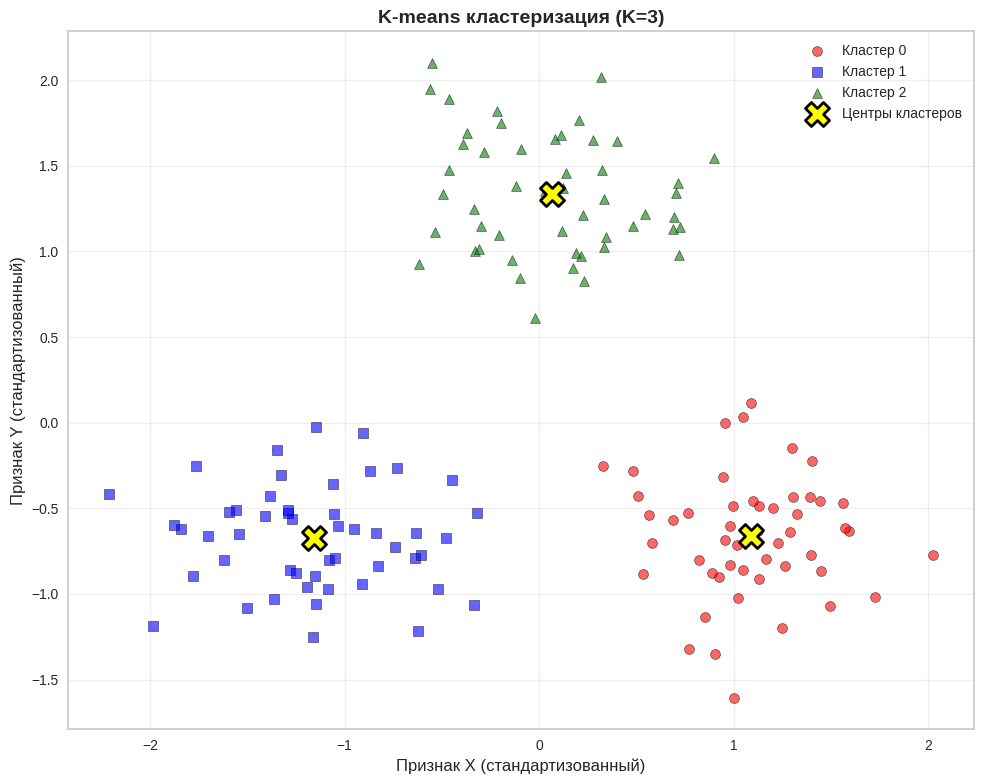

In [85]:
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']
for i in range(3):
    cluster_points = df_part1_scaled[labels_3 == i]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors[i],
        label=f'Кластер {i}',
        s=50,
        marker=markers[i],
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )

plt.scatter(
    kmeans_3.cluster_centers_[:, 0],
    kmeans_3.cluster_centers_[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolors='black',
    linewidth=2,
    label='Центры кластеров'
)

plt.title('K-means кластеризация (K=3)', fontsize=14, fontweight='bold')
plt.xlabel('Признак X (стандартизованный)', fontsize=12)
plt.ylabel('Признак Y (стандартизованный)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


График наглядно показывает три хорошо разделенных кластера.
Центроиды (желтые кресты) расположены в центрах кластеров.
Визуально подтверждается качество кластеризации.

### Коэффициент силуэта для K=3

Вычисляем коэффициент силуэта, который показывает качество кластеризации. Значения близкие к 1 указывают на хорошо разделённые кластеры.

In [86]:
silhouette_3 = silhouette_score(df_part1_scaled, labels_3)

print(f"Коэффициент силуэта для K=3: {silhouette_3:.4f}")
print(f"\nПояснение")
print(f"  - Значение близко к 1: кластеры хорошо разделены")
print(f"  - Значение близко к 0: кластеры перекрываются")
print(f"  - Значение отрицательное: объекты неправильно назначены кластерам")

Коэффициент силуэта для K=3: 0.6904

Пояснение
  - Значение близко к 1: кластеры хорошо разделены
  - Значение близко к 0: кластеры перекрываются
  - Значение отрицательное: объекты неправильно назначены кластерам


Силуэт = 0.6904 (близко к 1) - отличный результат.
Кластеры хорошо разделены, объекты правильно назначены.

### K-means кластеризация для K=2

In [87]:
kmeans_2 = KMeans(n_clusters=2, random_state=0)
labels_2 = kmeans_2.fit_predict(df_part1_scaled)
silhouette_2 = silhouette_score(df_part1_scaled, labels_2)

print(f"Результаты для K=2:")
print(f"Количество объектов в каждом кластере: {np.bincount(labels_2)}")
print(f"Коэффициент силуэта: {silhouette_2:.4f}")

Результаты для K=2:
Количество объектов в каждом кластере: [ 50 100]
Коэффициент силуэта: 0.4809


### Визуализация кластеров для K=2

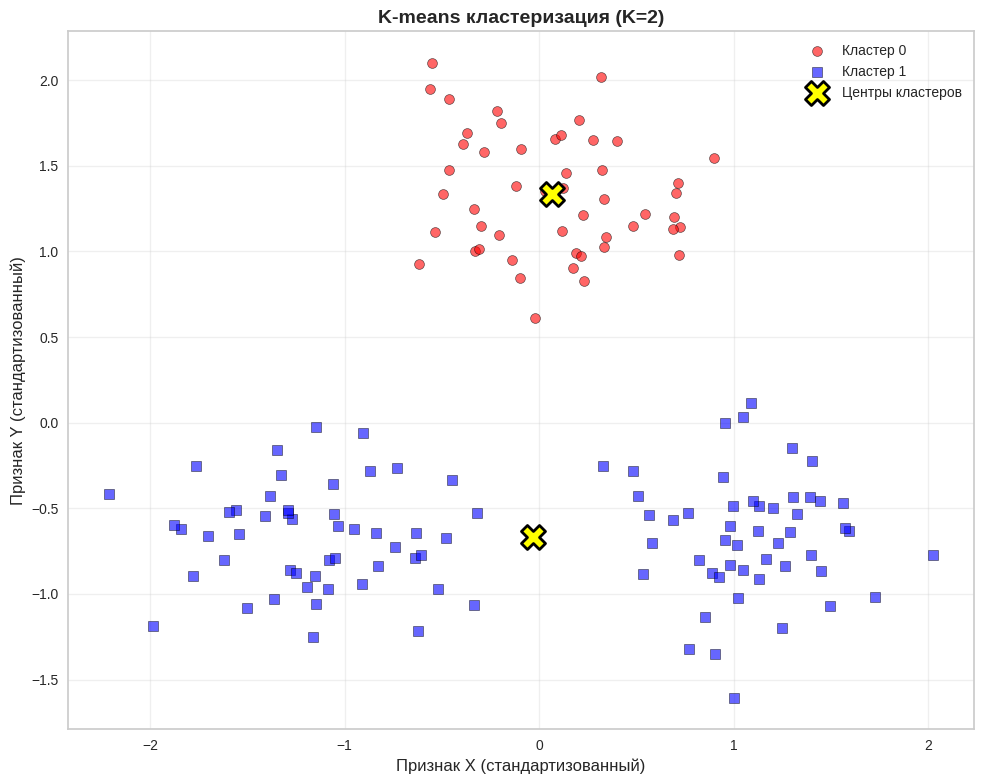

In [88]:
plt.figure(figsize=(10, 8))
colors_2 = ['red', 'blue']
markers_2 = ['o', 's']
for i in range(2):
    cluster_points = df_part1_scaled[labels_2 == i]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors_2[i],
        label=f'Кластер {i}',
        s=50,
        marker=markers_2[i],
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )

plt.scatter(
    kmeans_2.cluster_centers_[:, 0],
    kmeans_2.cluster_centers_[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolors='black',
    linewidth=2,
    label='Центры кластеров'
)

plt.title('K-means кластеризация (K=2)', fontsize=14, fontweight='bold')
plt.xlabel('Признак X (стандартизованный)', fontsize=12)
plt.ylabel('Признак Y (стандартизованный)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

При K=2 качество ухудшилось: силуэт = 0.4809.
На графике видно, что две естественные группы объединены в один кластер.

### K-means кластеризация для K=4

In [89]:
kmeans_4 = KMeans(n_clusters=4, random_state=0)
labels_4 = kmeans_4.fit_predict(df_part1_scaled)
silhouette_4 = silhouette_score(df_part1_scaled, labels_4)

print(f"Результаты для K=4:")
print(f"Количество объектов в каждом кластере: {np.bincount(labels_4)}")
print(f"Коэффициент силуэта: {silhouette_4:.4f}")

Результаты для K=4:
Количество объектов в каждом кластере: [22 50 28 50]
Коэффициент силуэта: 0.5721


### Визуализация кластеров для K=4

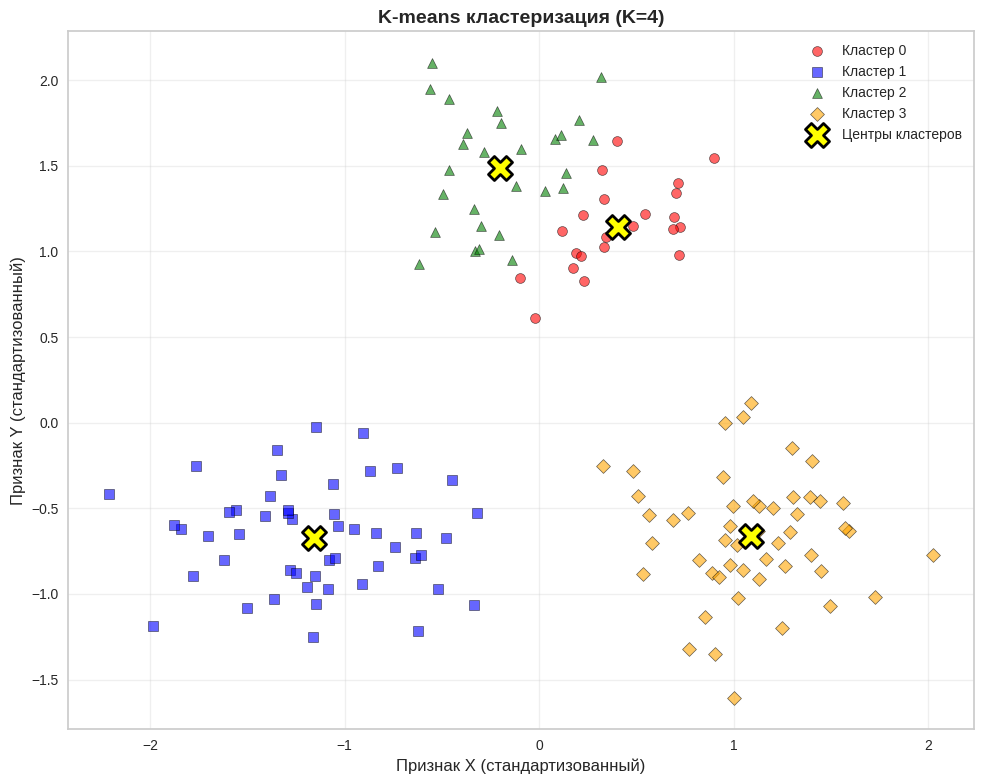

In [90]:
plt.figure(figsize=(10, 8))
colors_4 = ['red', 'blue', 'green', 'orange']
markers_4 = ['o', 's', '^', 'D']

for i in range(4):
    cluster_points = df_part1_scaled[labels_4 == i]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors_4[i],
        label=f'Кластер {i}',
        s=50,
        marker=markers_4[i],
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )

plt.scatter(
    kmeans_4.cluster_centers_[:, 0],
    kmeans_4.cluster_centers_[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolors='black',
    linewidth=2,
    label='Центры кластеров'
)

plt.title('K-means кластеризация (K=4)', fontsize=14, fontweight='bold')
plt.xlabel('Признак X (стандартизованный)', fontsize=12)
plt.ylabel('Признак Y (стандартизованный)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

При K=4 силуэт снизился до 0.5721.
Алгоритм разделил одну из естественных групп на два кластера.
Это пример "переобучения" кластеризации.

### Сравнение результатов для K=2, K=3, K=4

In [91]:
print("-"*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДЛЯ РАЗНЫХ КОЛИЧЕСТВ КЛАСТЕРОВ")
print("-"*60)

comparison_results = pd.DataFrame(
    {
        'K кластеров': [2, 3, 4],
        'Коэффициент силуэта': [silhouette_2, silhouette_3, silhouette_4],
        'Инертия (сумма квадратов)': [kmeans_2.inertia_, kmeans_3.inertia_, kmeans_4.inertia_],
        'Число итераций': [kmeans_2.n_iter_, kmeans_3.n_iter_, kmeans_4.n_iter_]
    }
)

print("\n" + comparison_results.to_string(index=False))

print("\n" + "-"*60)


------------------------------------------------------------
СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДЛЯ РАЗНЫХ КОЛИЧЕСТВ КЛАСТЕРОВ
------------------------------------------------------------

 K кластеров  Коэффициент силуэта  Инертия (сумма квадратов)  Число итераций
           2             0.480873                 165.832386               5
           3             0.690397                  39.820693               4
           4             0.572101                  33.762359               3

------------------------------------------------------------


ВЫВОДЫ

K=3 даёт наивысший коэффициент силуэта, что соответствует трём группам в исходных данных.
К увеличению K от 2 к 3 приводит к улучшению качества.")
print("3. При K=4 качество немного снижается, так как четвёртый кластер разбивает одну из основных групп.
Инертия закономерно снижается с увеличением K, но это не всегда означает лучшую кластеризацию.

### Метод локтя (Elbow Method)

Строим график зависимости инертии от количества кластеров для визуального определения оптимального K.

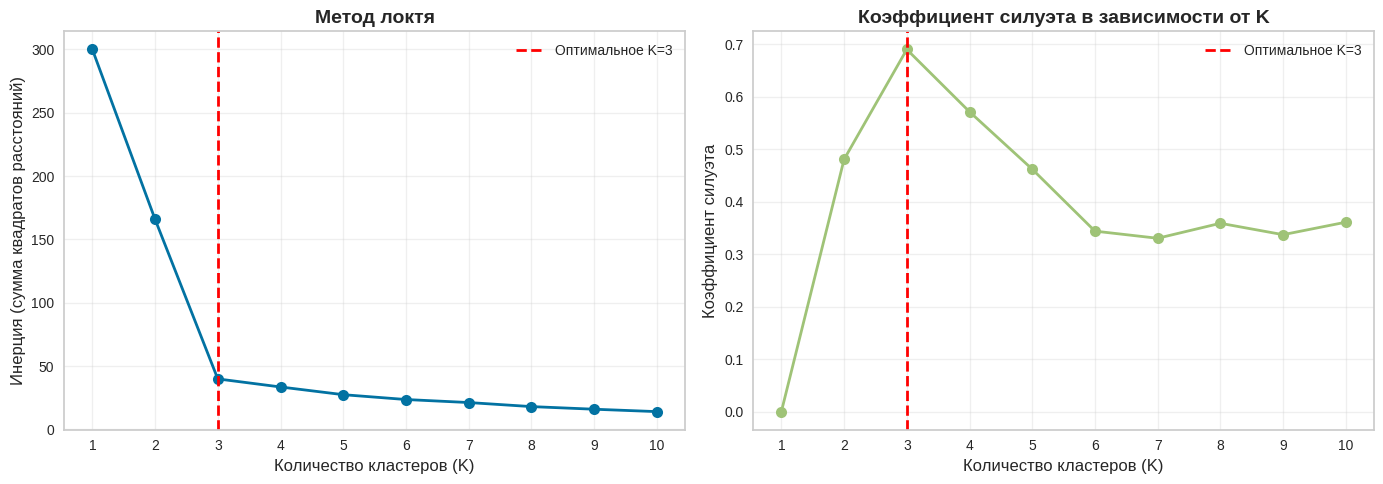

Оба графика показывают, что оптимальное K=3:
  - На графике инертии точка излома (локоть) находится при K=3
  - Коэффициент силуэта максимален при K=3


Вывод инерции и коэффициентов силуэта:
[299.99999999999994, 165.83238641166548, 39.82069276129826, 33.455042388095386, 27.367975444124237, 23.545792993547252, 21.165709529482445, 17.960391515062692, 15.887287690647954, 13.99515272949039]
[0.0, 0.4808729921486443, 0.6903971706728537, 0.5716069307756713, 0.4621593973750955, 0.3440450195480984, 0.3304363890270608, 0.3590166611797404, 0.33729246330914414, 0.3610823167376798]


In [92]:
inertias = []
silhouette_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans_temp.fit(df_part1_scaled)
    inertias.append(kmeans_temp.inertia_)
    if k > 1:
        silhouette_scores.append(silhouette_score(df_part1_scaled, kmeans_temp.labels_))
    else:
        silhouette_scores.append(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='Оптимальное K=3')
axes[0].set_xlabel('Количество кластеров (K)', fontsize=12)
axes[0].set_ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
axes[0].set_title('Метод локтя', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=2, label='Оптимальное K=3')
axes[1].set_xlabel('Количество кластеров (K)', fontsize=12)
axes[1].set_ylabel('Коэффициент силуэта', fontsize=12)
axes[1].set_title('Коэффициент силуэта в зависимости от K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()


print("Оба графика показывают, что оптимальное K=3:")
print(f"  - На графике инертии точка излома (локоть) находится при K=3")
print(f"  - Коэффициент силуэта максимален при K=3")
print(f"\n\nВывод инерции и коэффициентов силуэта:")
print(inertias)
print(list(map(float, silhouette_scores)))

График метода локтя явно показывает излом при K=3.
График силуэта подтверждает максимум при K=3.
Оба метода согласованно указывают на оптимальное количество кластеров.

### **Визуализация силуэтов для кластеров**
Необходимо проанализировать плотность распределения кластеров - какие из них по сути являются бесполезными. В этом помогает SilhouetteVisualizer:

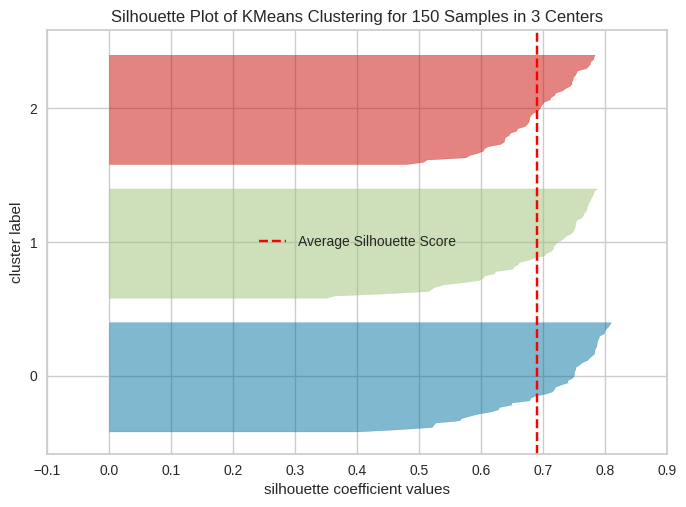

In [93]:
model = KMeans(n_clusters=3, random_state=0)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(df_part1_scaled)
visualizer.show()
plt.show()

Диаграмма силуэтов показывает высокие и однородные значения для всех кластеров.
Все значения выше среднего по датасету.
Отрицательные значения практически отсутствуют - кластеризация качественная.

## Часть 2: Кластеризация реального датасета medical_diagnosis

### Загрузка и первичный анализ данных

Загружаем датасет о медицинской диагностике.

In [94]:
df = pd.read_csv('medical_diagnosis.csv')

print(f"Размер датасета: {df.shape}")
print(f"\nИмена признаков:")
display(df.columns.tolist())
print(f"\nТипы данных:")
display(df.dtypes)
print(f"\nПервые строки датасета:")
display(df.head(20))

Размер датасета: (3031, 14)

Имена признаков:


['age',
 'sex',
 'BMI',
 'systolic_bp',
 'cholesterol_mg_dl',
 'fasting_glucose_mg_dl',
 'smoking_status',
 'family_history',
 'activity_level',
 'symptom_score',
 'CRP_mg_L',
 'WBC_10e9_L',
 'ECG_result',
 'Disease']


Типы данных:


,0
age,int64
sex,object
BMI,float64
systolic_bp,float64
cholesterol_mg_dl,float64
fasting_glucose_mg_dl,float64
smoking_status,object
family_history,object
activity_level,object
symptom_score,float64



Первые строки датасета:


,age,sex,BMI,systolic_bp,cholesterol_mg_dl,fasting_glucose_mg_dl,smoking_status,family_history,activity_level,symptom_score,CRP_mg_L,WBC_10e9_L,ECG_result,Disease
0,34,Male,16.8,132.0,196.0,78.0,Current,No,High,0.2,0.58,8.60,Normal,0
1,24,Female,29.2,118.0,182.0,96.0,Current,No,Moderate,3.2,2.72,6.54,Normal,0
2,19,Female,16.5,121.0,268.0,101.0,Current,No,Moderate,3.8,0.18,6.61,Normal,0
3,89,Female,15.4,117.0,136.0,96.0,Never,No,Low,2.6,1.83,5.67,Normal,0
4,66,Male,16.7,82.0,241.0,126.0,Former,No,Moderate,3.5,1.16,2.66,Normal,0
5,43,Male,13.5,136.0,171.0,91.0,Never,No,Low,1.3,0.10,5.05,ST-T abnormality,0
6,76,Female,26.2,110.0,269.0,140.0,Current,Yes,Moderate,2.7,2.92,7.91,ST-T abnormality,0
7,24,Female,30.0,162.0,189.0,112.0,Never,Yes,High,2.1,0.80,7.71,LVH,0
8,83,Male,25.7,107.0,215.0,110.0,Never,No,Moderate,2.7,2.60,9.17,Normal,0
9,41,Female,21.5,156.0,188.0,120.0,Never,No,High,1.1,0.10,10.15,Normal,0


### Предварительная обработка данных

Проверяем пропуски, пропускаем целевую переменную и обрабатываем категориальные признаки.

In [95]:
print("Проверка пропущенных значений:")
display(df.isnull().sum())
target = df['Disease'].copy()
df_features = df.drop('Disease', axis=1)

print(f"\nЦелевая переменная распределение:")
print(target.value_counts())
print(f"\nПроцент больных: {(target.sum() / len(target) * 100):.2f}%")

Проверка пропущенных значений:


,0
age,0
sex,0
BMI,0
systolic_bp,0
cholesterol_mg_dl,0
fasting_glucose_mg_dl,0
smoking_status,0
family_history,0
activity_level,0
symptom_score,0



Целевая переменная распределение:
Disease
0    2982
1      49
Name: count, dtype: int64

Процент больных: 1.62%


### Матрица диаграмм рассеяния с выделением целевой переменной

Строим пары признаков, выделяя значения целевой переменной разными цветами.

Распределение целевой переменной (Disease):
Disease
0    2982
1      49
Name: count, dtype: int64

Процент больных: 1.62%

Численные признаки: ['age', 'BMI', 'systolic_bp', 'cholesterol_mg_dl', 'fasting_glucose_mg_dl', 'symptom_score', 'CRP_mg_L', 'WBC_10e9_L']


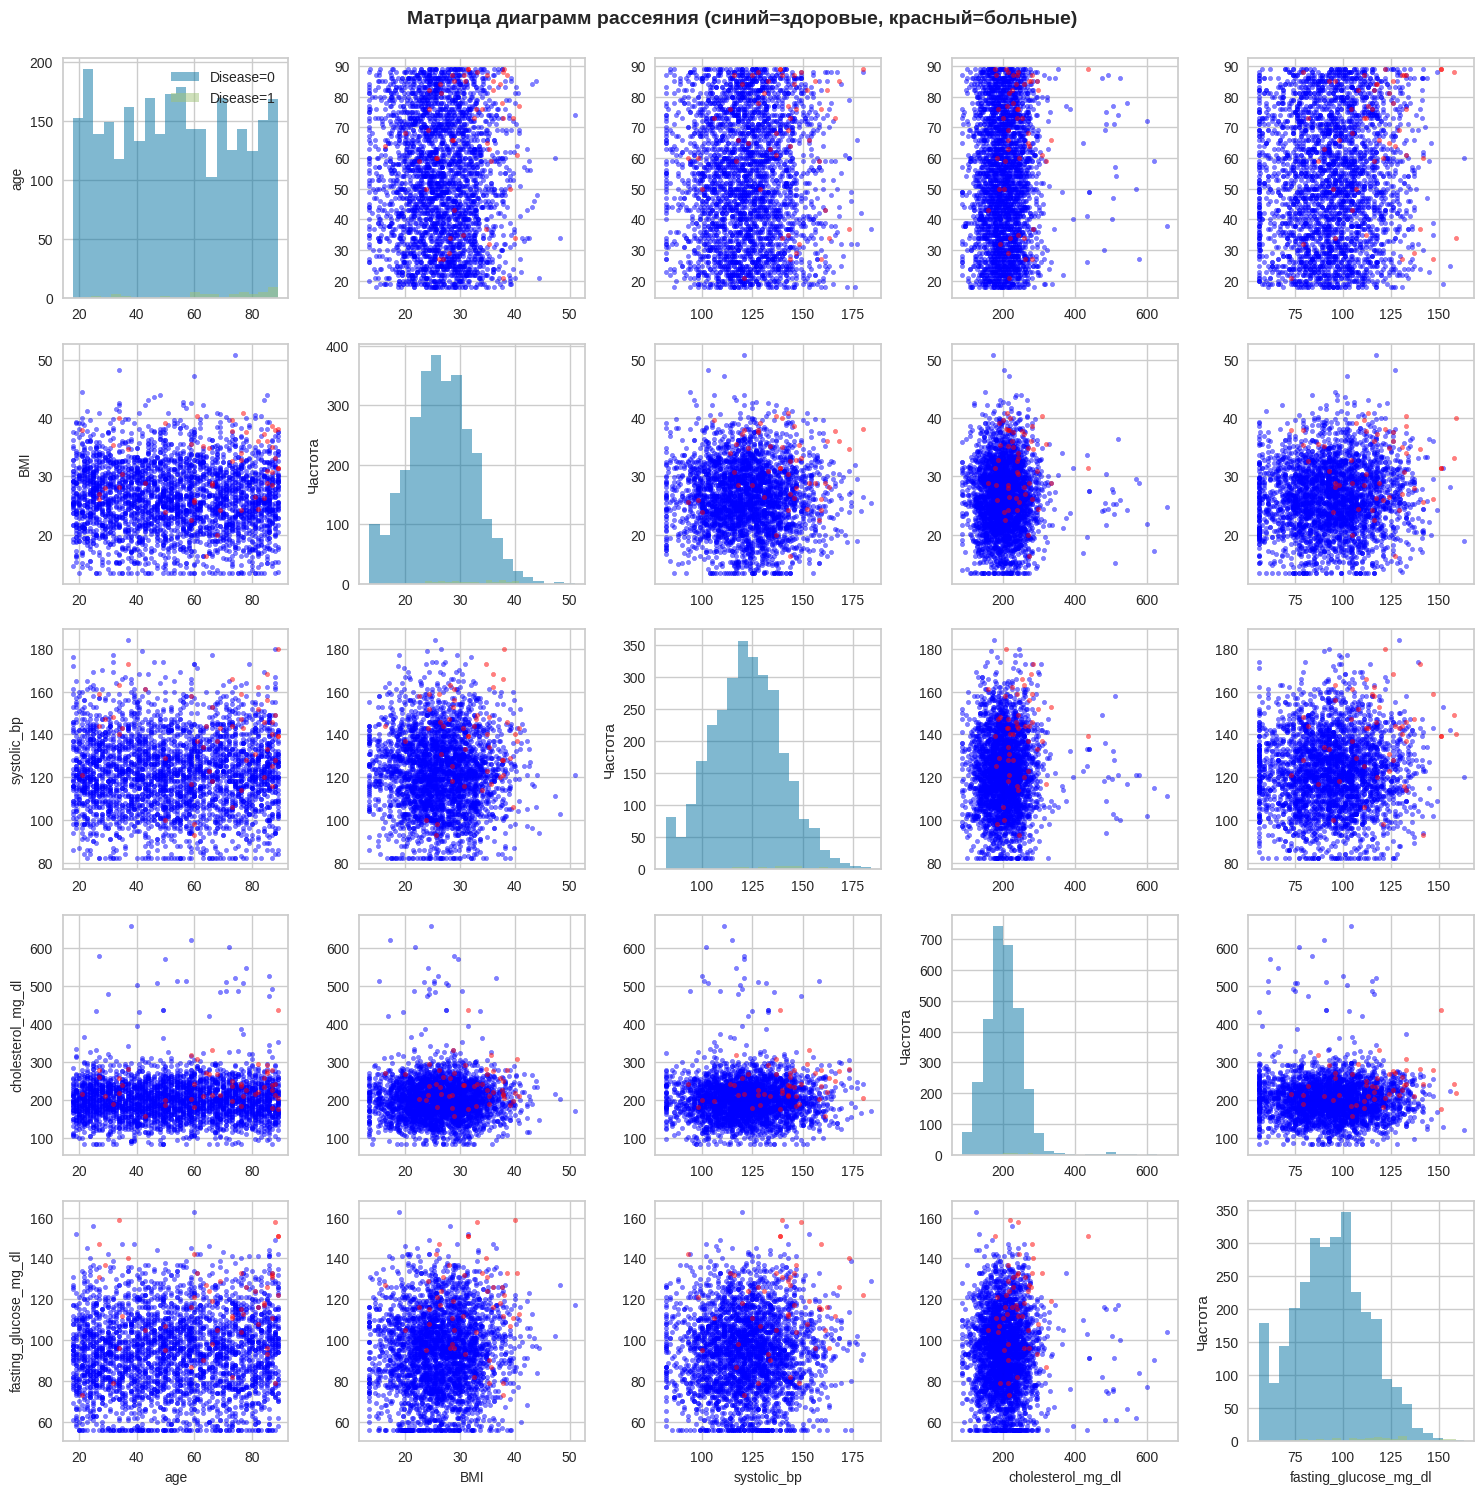

In [96]:
# Выделение целевой переменной
target = df['Disease'].copy()
df_features = df.drop('Disease', axis=1)

print(f"Распределение целевой переменной (Disease):")
print(target.value_counts())
print(f"\nПроцент больных: {(target.sum() / len(target) * 100):.2f}%")

# Матрица диаграмм рассеяния
numeric_features = df_features.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nЧисленные признаки: {numeric_features}")

selected_features = numeric_features[:5]  # Выбираем первые 5 признаков для визуализации
plot_data = df_features[selected_features].copy()
plot_data['Disease'] = target

fig, axes = plt.subplots(len(selected_features), len(selected_features), figsize=(15, 15))

for i in range(len(selected_features)):
    for j in range(len(selected_features)):
        ax = axes[i, j]
        if i == j:
            # Гистограмма на диагонали
            for disease_class in [0, 1]:
                data_class = plot_data[plot_data['Disease'] == disease_class][selected_features[i]]
                ax.hist(data_class, alpha=0.5, label=f'Disease={disease_class}', bins=20)
            ax.set_ylabel('Частота')
            if j == 0:
                ax.legend()
        else:
            # Диаграмма рассеяния
            for disease_class in [0, 1]:
                data_class = plot_data[plot_data['Disease'] == disease_class]
                color = 'red' if disease_class == 1 else 'blue'
                ax.scatter(data_class[selected_features[j]],
                          data_class[selected_features[i]],
                          alpha=0.5, s=10, c=color, label=f'Disease={disease_class}')

        # Подписи осей
        if j == 0:
            ax.set_ylabel(selected_features[i], fontsize=10)
        if i == len(selected_features) - 1:
            ax.set_xlabel(selected_features[j], fontsize=10)

plt.suptitle('Матрица диаграмм рассеяния (синий=здоровые, красный=больные)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

На графиках видно сильное перекрытие классов "здоровые" и "больные".
Нет явной линейной разделимости признаков.
Это указывает на сложность задачи кластеризации.

### Обработка категориальных признаков

Преобразуем категориальные признаки в численные, используя One-Hot Encoding и Label Encoding.

In [97]:
# Обработка категориальных признаков
categorical_features = df_features.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {categorical_features}")

df_encoded = df_features.copy()

# Label Encoding для бинарных признаков
le = LabelEncoder()
df_encoded['sex'] = le.fit_transform(df_encoded['sex'])  # Male=1, Female=0
df_encoded['family_history'] = le.fit_transform(df_encoded['family_history'])  # Yes=1, No=0

# One-Hot Encoding для остальных категориальных признаков
df_encoded = pd.get_dummies(df_encoded,
                           columns=['smoking_status', 'activity_level', 'ECG_result'],
                           drop_first=True)

print(f"\nРазмер датасета после кодирования: {df_encoded.shape}")
print(f"Количество признаков: {df_encoded.shape[1]}")
display(df_encoded)



Категориальные признаки: ['sex', 'smoking_status', 'family_history', 'activity_level', 'ECG_result']

Размер датасета после кодирования: (3031, 16)
Количество признаков: 16


,age,sex,BMI,systolic_bp,cholesterol_mg_dl,fasting_glucose_mg_dl,family_history,symptom_score,CRP_mg_L,WBC_10e9_L,smoking_status_Former,smoking_status_Never,activity_level_Low,activity_level_Moderate,ECG_result_Normal,ECG_result_ST-T abnormality
0,34,1,16.8,132.0,196.0,78.0,0,0.2,0.58,8.60,False,False,False,False,True,False
1,24,0,29.2,118.0,182.0,96.0,0,3.2,2.72,6.54,False,False,False,True,True,False
2,19,0,16.5,121.0,268.0,101.0,0,3.8,0.18,6.61,False,False,False,True,True,False
3,89,0,15.4,117.0,136.0,96.0,0,2.6,1.83,5.67,False,True,True,False,True,False
4,66,1,16.7,82.0,241.0,126.0,0,3.5,1.16,2.66,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3026,40,0,27.8,119.0,503.4,102.0,0,0.0,24.48,7.80,False,False,False,True,False,True
3027,57,0,15.2,158.0,512.4,115.0,1,3.1,24.27,6.51,False,True,True,False,False,False
3028,41,1,19.7,133.0,433.2,56.0,1,0.0,20.35,8.20,True,False,False,True,True,False
3029,75,1,30.4,94.0,487.2,75.0,0,1.4,33.09,8.11,True,False,False,True,True,False


### Стандартизация данных

Применяем стандартизацию для приведения данных к единому масштабу.

In [98]:
# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print(f"\nДанные после стандартизации:")
print(f"Среднее значение: {X_scaled.mean(axis=0)[:5]}")
print(f"Стандартное отклонение: {X_scaled.std(axis=0)[:5]}")
print("\nДанные готовы к кластеризации")



Данные после стандартизации:
Среднее значение: [ 2.34425185e-17 -3.75080296e-17 -5.54415563e-16 -1.19556844e-16
 -2.53179200e-16]
Стандартное отклонение: [1. 1. 1. 1. 1.]

Данные готовы к кластеризации


### Выбор оптимального количества кластеров (метод локтя + силуэт)

Используем метод локтя и коэффициент силуэта для определения оптимального количества кластеров.

In [99]:
# Метод локтя и коэффициент силуэта
inertias = []
silhouette_scores = []
k_range = range(2, 11)

print("Вычисление метрик для разных количеств кластеров...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k}: Инерция={kmeans.inertia_:.2f}, Силуэт={silhouette_scores[-1]:.4f}")


Вычисление метрик для разных количеств кластеров...
K=2: Инерция=43085.07, Силуэт=0.1664
K=3: Инерция=39515.50, Силуэт=0.1124
K=4: Инерция=36945.33, Силуэт=0.1093
K=5: Инерция=34129.53, Силуэт=0.1189
K=6: Инерция=33038.15, Силуэт=0.1125
K=7: Инерция=31891.69, Силуэт=0.1075
K=8: Инерция=31094.04, Силуэт=0.1089
K=9: Инерция=30379.35, Силуэт=0.1010
K=10: Инерция=29775.09, Силуэт=0.1014


### Визуализация метода локтя и коэффициента силуэта

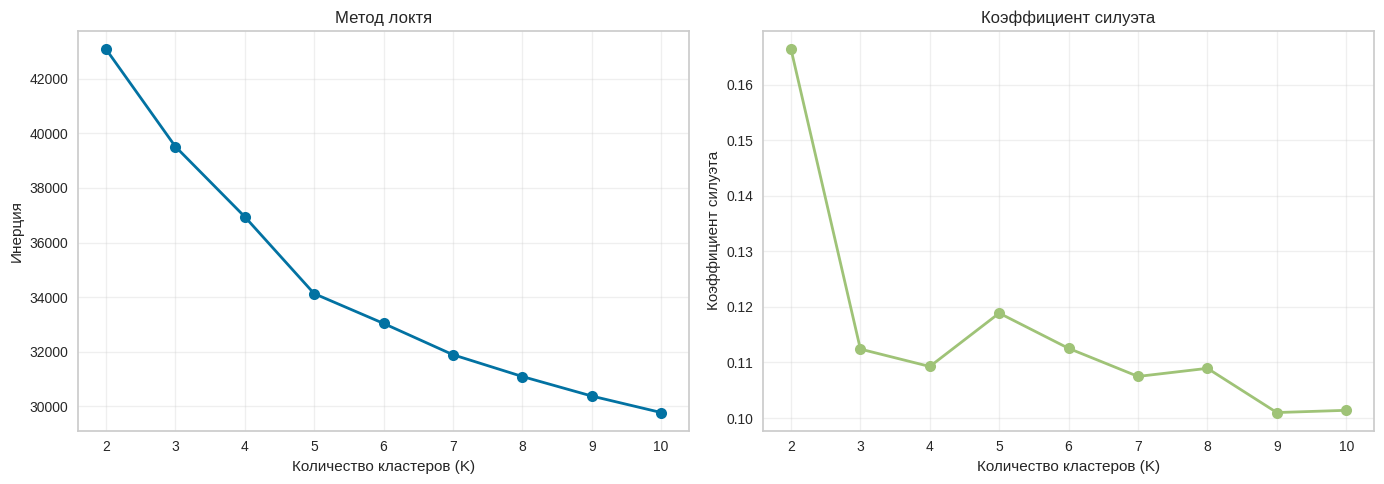


Оптимальное количество кластеров по коэффициенту силуэта: K=2
Максимальный коэффициент силуэта: 0.1664


In [100]:
# Визуализация метода локтя и коэффициента силуэта
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Метод локтя
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (K)')
axes[0].set_ylabel('Инерция')
axes[0].set_title('Метод локтя')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range)

# Коэффициент силуэта
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров (K)')
axes[1].set_ylabel('Коэффициент силуэта')
axes[1].set_title('Коэффициент силуэта')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

# Определение оптимального K
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nОптимальное количество кластеров по коэффициенту силуэта: K={optimal_k}")
print(f"Максимальный коэффициент силуэта: {max(silhouette_scores):.4f}")

ВЫВОД

Коэффициент силуэта для всех K низкий (0.10-0.17).
Метод локтя не показывает четкого "излома".
Оптимальное K=2 (максимум силуэта 0.1664), но качество все равно плохое.

### K-means кластеризация с оптимальным K

In [101]:
# Кластеризация с оптимальным K
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_kmeans = kmeans_optimal.fit_predict(X_scaled)

# Добавление меток кластеров к исходным данным
df_clustered = df.copy()
df_clustered['Cluster'] = clusters_kmeans

display(df_clustered)
print(f"Распределение пациентов по кластерам:")
print(df_clustered['Cluster'].value_counts().sort_index())
print(f"\nПроцентное распределение:")
print((df_clustered['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2))

,age,sex,BMI,systolic_bp,cholesterol_mg_dl,fasting_glucose_mg_dl,smoking_status,family_history,activity_level,symptom_score,CRP_mg_L,WBC_10e9_L,ECG_result,Disease,Cluster
0,34,Male,16.8,132.0,196.0,78.0,Current,No,High,0.2,0.58,8.60,Normal,0,0
1,24,Female,29.2,118.0,182.0,96.0,Current,No,Moderate,3.2,2.72,6.54,Normal,0,0
2,19,Female,16.5,121.0,268.0,101.0,Current,No,Moderate,3.8,0.18,6.61,Normal,0,0
3,89,Female,15.4,117.0,136.0,96.0,Never,No,Low,2.6,1.83,5.67,Normal,0,0
4,66,Male,16.7,82.0,241.0,126.0,Former,No,Moderate,3.5,1.16,2.66,Normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3026,40,Female,27.8,119.0,503.4,102.0,Current,No,Moderate,0.0,24.48,7.80,ST-T abnormality,0,1
3027,57,Female,15.2,158.0,512.4,115.0,Never,Yes,Low,3.1,24.27,6.51,LVH,0,1
3028,41,Male,19.7,133.0,433.2,56.0,Former,Yes,Moderate,0.0,20.35,8.20,Normal,0,0
3029,75,Male,30.4,94.0,487.2,75.0,Former,No,Moderate,1.4,33.09,8.11,Normal,0,0


Распределение пациентов по кластерам:
Cluster
0    2382
1     649
Name: count, dtype: int64

Процентное распределение:
Cluster
0    78.59
1    21.41
Name: proportion, dtype: float64


### Анализ характеристик каждого кластера

Вычисляем средние значения признаков для каждого кластера.

In [102]:
# Анализ характеристик кластеров
numeric_features_analysis = ['age', 'BMI', 'systolic_bp', 'cholesterol_mg_dl',
                            'fasting_glucose_mg_dl', 'symptom_score',
                            'CRP_mg_L', 'WBC_10e9_L']

print(f"\nСРЕДНИЕ ЗНАЧЕНИЯ ПРИЗНАКОВ ПО КЛАСТЕРАМ:")


for cluster_id in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    cluster_size = len(cluster_data)
    disease_rate = cluster_data['Disease'].mean() * 100

    print(f"\nКЛАСТЕР {cluster_id}:")
    print(f"  Размер: {cluster_size} пациентов ({cluster_size/len(df_clustered)*100:.1f}%)")
    print(f"  Процент больных: {disease_rate:.1f}%")
    print(f"  Средний возраст: {cluster_data['age'].mean():.1f} лет")
    print(f"  Средний BMI: {cluster_data['BMI'].mean():.1f}")
    print(f"  Среднее давление: {cluster_data['systolic_bp'].mean():.1f} мм рт.ст.")
    print(f"  Средний холестерин: {cluster_data['cholesterol_mg_dl'].mean():.1f} мг/дл")
    print(f"  Средняя глюкоза: {cluster_data['fasting_glucose_mg_dl'].mean():.1f} мг/дл")

    # Определение типа кластера
    if disease_rate > 60:
        print(f"  ТИП: Высокий риск заболеваний")
    elif disease_rate > 30:
        print(f"  ТИП: Средний риск заболеваний")
    else:
        print(f"  ТИП: Низкий риск заболеваний")


СРЕДНИЕ ЗНАЧЕНИЯ ПРИЗНАКОВ ПО КЛАСТЕРАМ:

КЛАСТЕР 0:
  Размер: 2382 пациентов (78.6%)
  Процент больных: 1.6%
  Средний возраст: 52.8 лет
  Средний BMI: 26.4
  Среднее давление: 122.1 мм рт.ст.
  Средний холестерин: 202.0 мг/дл
  Средняя глюкоза: 94.3 мг/дл
  ТИП: Низкий риск заболеваний

КЛАСТЕР 1:
  Размер: 649 пациентов (21.4%)
  Процент больных: 1.5%
  Средний возраст: 54.5 лет
  Средний BMI: 26.6
  Среднее давление: 123.6 мм рт.ст.
  Средний холестерин: 205.6 мг/дл
  Средняя глюкоза: 94.8 мг/дл
  ТИП: Низкий риск заболеваний


Оба кластера имеют практически одинаковый процент больных (~1.5-1.6%).
Средние значения медицинских показателей очень близки.
Кластеры не соответствуют различию "здоровые/больные".

### Метрики качества кластеризации K-means

In [103]:
# Вычисление метрик
silhouette_kmeans = silhouette_score(X_scaled, clusters_kmeans)
ami_kmeans = adjusted_mutual_info_score(target, clusters_kmeans)
ari_kmeans = adjusted_rand_score(target, clusters_kmeans)
homogeneity_kmeans = homogeneity_score(target, clusters_kmeans)
completeness_kmeans = completeness_score(target, clusters_kmeans)
v_measure_kmeans = v_measure_score(target, clusters_kmeans)

metrics_kmeans = pd.DataFrame({
    'Метрика': ['Silhouette Score', 'Adjusted Mutual Information',
                'Adjusted Rand Index', 'Homogeneity Score',
                'Completeness Score', 'V-measure'],
    'Значение': [silhouette_kmeans, ami_kmeans, ari_kmeans,
                 homogeneity_kmeans, completeness_kmeans, v_measure_kmeans]
})

print(metrics_kmeans.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


print(f"- Silhouette Score ({silhouette_kmeans:.4f}): чем ближе к 1, тем лучше разделены кластеры")
print(f"- Adjusted Mutual Information ({ami_kmeans:.4f}): измеряет согласованность с истинными метками")
print(f"- Adjusted Rand Index ({ari_kmeans:.4f}): измеряет сходство кластеризации с истинными метками")

                    Метрика  Значение
           Silhouette Score    0.1664
Adjusted Mutual Information   -0.0005
        Adjusted Rand Index   -0.0011
          Homogeneity Score    0.0001
         Completeness Score    0.0000
                  V-measure    0.0000
- Silhouette Score (0.1664): чем ближе к 1, тем лучше разделены кластеры
- Adjusted Mutual Information (-0.0005): измеряет согласованность с истинными метками
- Adjusted Rand Index (-0.0011): измеряет сходство кластеризации с истинными метками


Все метрики показывают низкое качество:
Silhouette: 0.1664 (плохо)
AMI: -0.0005 (отсутствие связи с истинными метками)


### Иерархическая агломеративная кластеризация

In [104]:
# Иерархическая кластеризация
agg_clustering = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage='ward'
)
clusters_agg = agg_clustering.fit_predict(X_scaled)

df_clustered_agg = df.copy()
df_clustered_agg['Cluster_Agg'] = clusters_agg

print(f"Распределение пациентов по кластерам (агломеративная кластеризация):")
cluster_counts = np.bincount(clusters_agg)
for cluster_id, count in enumerate(cluster_counts):
    print(f"Кластер {cluster_id}: {count} пациентов ({count/len(clusters_agg)*100:.1f}%)")



Распределение пациентов по кластерам (агломеративная кластеризация):
Кластер 0: 2410 пациентов (79.5%)
Кластер 1: 621 пациентов (20.5%)


### Построение дендрограммы для иерархической кластеризации


Построение дендрограммы...


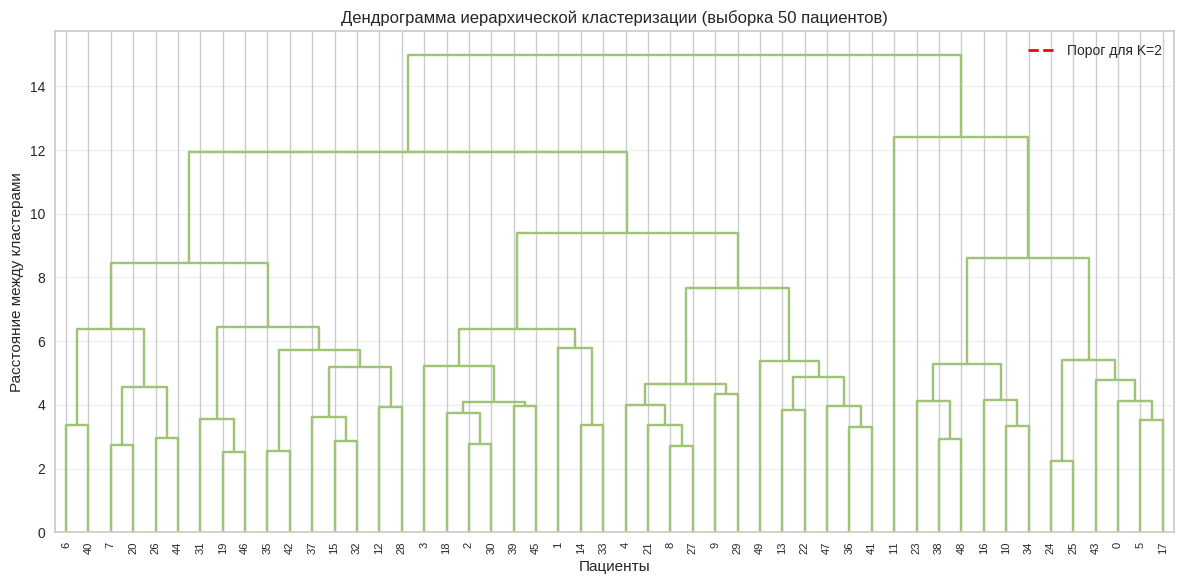

Дендрограмма показывает иерархическое объединение пациентов.
Красная линия показывает уровень отсечения для получения оптимального количества кластеров.


In [111]:
# Построение дендрограммы
print(f"\nПостроение дендрограммы...")
sample_size = min(50, X_scaled.shape[0])
sample_indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[sample_indices]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', color_threshold=25)
plt.title(f'Дендрограмма иерархической кластеризации (выборка {sample_size} пациентов)')
plt.xlabel('Пациенты')
plt.ylabel('Расстояние между кластерами')
plt.axhline(y=25, color='red', linestyle='--', linewidth=2,
           label=f'Порог для K={optimal_k}')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Дендрограмма показывает иерархическое объединение пациентов.")
print("Красная линия показывает уровень отсечения для получения оптимального количества кластеров.")



Дендрограмма показывает отсутствие четкой иерархической структуры.
Длинные вертикальные линии указывают на объединение непохожих групп.

### Анализ характеристик кластеров (агломеративная кластеризация)

In [106]:
# Анализ характеристик кластеров (агломеративная кластеризация)
print(f"\nАНАЛИЗ КЛАСТЕРОВ (АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ):")

for cluster_id in range(optimal_k):
    cluster_data = df_clustered_agg[df_clustered_agg['Cluster_Agg'] == cluster_id]
    cluster_size = len(cluster_data)
    disease_rate = cluster_data['Disease'].mean() * 100

    print(f"\nКЛАСТЕР {cluster_id}:")
    print(f"  Размер: {cluster_size} пациентов")
    print(f"  Процент больных: {disease_rate:.1f}%")
    print(f"  Средний возраст: {cluster_data['age'].mean():.1f} лет")
    print(f"  Средний BMI: {cluster_data['BMI'].mean():.1f}")
    print(f"  Среднее давление: {cluster_data['systolic_bp'].mean():.1f} мм рт.ст.")


АНАЛИЗ КЛАСТЕРОВ (АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ):

КЛАСТЕР 0:
  Размер: 2410 пациентов
  Процент больных: 1.7%
  Средний возраст: 52.9 лет
  Средний BMI: 26.4
  Среднее давление: 122.1 мм рт.ст.

КЛАСТЕР 1:
  Размер: 621 пациентов
  Процент больных: 1.3%
  Средний возраст: 54.3 лет
  Средний BMI: 26.7
  Среднее давление: 123.6 мм рт.ст.


Результаты аналогичны K-means: кластеры практически одинаковы.
Процент больных в обоих кластерах ~1.5-1.7%.
Нет медицински значимого разделения.

### Метрики качества кластеризации (агломеративная кластеризация)

In [107]:
# Метрики качества для агломеративной кластеризации
print(f"\nМЕТРИКИ КАЧЕСТВА (АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ):")

silhouette_agg = silhouette_score(X_scaled, clusters_agg)
ami_agg = adjusted_mutual_info_score(target, clusters_agg)
ari_agg = adjusted_rand_score(target, clusters_agg)

metrics_agg = pd.DataFrame({
    'Метрика': ['Silhouette Score', 'Adjusted Mutual Information', 'Adjusted Rand Index'],
    'Значение': [silhouette_agg, ami_agg, ari_agg]
})

print(metrics_agg.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


МЕТРИКИ КАЧЕСТВА (АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ):
                    Метрика  Значение
           Silhouette Score    0.1592
Adjusted Mutual Information   -0.0003
        Adjusted Rand Index   -0.0046


### Сравнение методов

In [108]:
# Сравнение методов
comparison_df = pd.DataFrame({
    'Метрика': ['Silhouette Score', 'Adjusted Mutual Information', 'Adjusted Rand Index'],
    'K-means': [silhouette_kmeans, ami_kmeans, ari_kmeans],
    'Агломеративная': [silhouette_agg, ami_agg, ari_agg]
})

print("СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:")
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:
                    Метрика  K-means  Агломеративная
           Silhouette Score   0.1664          0.1592
Adjusted Mutual Information  -0.0005         -0.0003
        Adjusted Rand Index  -0.0011         -0.0046


Оба метода показывают сравнимые результаты.
K-means немного лучше по силуэту (0.1664 vs 0.1592).
Ни один метод не смог выделить значимые кластеры.

## Общие выводы

### Выводы работы

Часть 1: Синтетические данные

На синтетических данных с четкой структурой K-means показал отличные результаты.

Оптимальное количество кластеров K=3 было успешно определено обоими методами (локтя и силуэта).

Коэффициент силуэта 0.6904 подтвердил высокое качество кластеризации.

Визуализация четко показала три хорошо разделенных группы.

Часть 2: Реальные данные Medical Diagnosis

Основной результат: Кластеризация неэффективна для данного датасета в контексте выделения групп, связанных с заболеванием.

Причины:

Низкие значения всех метрик качества (силуэт < 0.17).

Отрицательные значения AMI и ARI указывают на отсутствие связи с истинными метками заболевания.

Оба метода (K-means и агломеративная) дали практически идентичные, но бессмысленные с медицинской точки зрения кластеры.

Особенности данных:

Сильная несбалансированность (всего 1.6% больных).

Отсутствие явных кластерных структур в данных.

Признаки не позволяют выделить компактные группы, соответствующие заболеванию.

Сравнение методов:

K-means и агломеративная кластеризация показали сравнимые результаты.

K-means оказался проще в использовании и немного лучше по метрикам.

Оба метода не справились с задачей из-за данных.

Рекомендации:

Смена подхода: Для данного датасета кластеризация не подходит.
Использование алгоритмов, не требующих задания числа кластеров (DBSCAN).

Практический вывод: Кластеризация - мощный инструмент, но его эффективность сильно зависит от структуры данных. В реальных задачах необходимо тщательно оценивать метрики качества и интерпретируемость результатов.

Заключение: Работа продемонстрировала важность выбора методов машинного обучения в зависимости от специфики данных. В то время как на синтетических данных кластеризация показала отличные результаты, на реальных медицинских данных она оказалась неэффективной, что указывает на необходимость применения других подходов для решения конкретной задачи прогнозирования заболеваний.

